# CNC Surface Roughness Prediction Using Multiple Linear Regression

This project investigates the relationship between CNC turning parameters and surface roughness using experimental machining data.

Cutting speed, feed rate, and depth of cut are used as machining parameters, while surface roughness is treated as the response variable.

The analysis includes data exploration, multiple linear regression, model evaluation, cross-validation, residual analysis, and interpretation of machining parameters.

## 1. Introduction

Surface roughness is an important indicator of machining quality and can be influenced by several cutting conditions.

In this project, experimental CNC turning data is used to study how cutting speed, feed rate, and depth of cut are related to surface roughness.

Multiple linear regression is used as the main modelling approach because it provides an interpretable relationship between the machining parameters and the response variable.

### Objectives

- Explore the experimental machining dataset
- Examine the relationship between machining parameters and surface roughness
- Build a multiple linear regression model
- Evaluate model performance using appropriate regression metrics
- Validate the model using cross-validation
- Analyze residuals and prediction errors
- Interpret the effect of machining parameters on surface roughness

## 2. Setup

The analysis uses Pandas and NumPy for data handling, Matplotlib and Seaborn for visualization, and Scikit-learn for regression modelling and evaluation.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 3. Dataset

The dataset contains experimental CNC turning measurements collected under different machining conditions.

The main variables used in this project are:

- **Cutting Speed** - machining speed
- **Feed Rate** - tool feed per revolution
- **Depth of Cut** - cutting depth
- **Surface Roughness (Ra)** - response variable representing the resulting surface finish

The dataset also contains additional experimental measurements, which will be inspected before selecting the final modelling variables.

In [2]:
df = pd.read_csv("Exp1.csv")

df.head()

,Run_ID,Experiment,Replica,Tool_ID,Group,Subgroup,Position,Condition,TCond,Machined_length,...,Ra,Rz,Rsk,Rku,RSm,Rt,Fx,Fy,Fz,F
0,1_021_B1_4_a,1,1,21,1,2,a,4,0,12,...,0.391,1.855,0.560,2.423,71.4,2.082,49.23,44.46,21.07,69.600499
1,1_021_B1_4_a,1,1,21,1,2,a,4,0,12,...,0.359,1.670,0.530,2.229,70.9,1.918,49.23,44.46,21.07,69.600499
2,1_021_B1_4_a,1,1,21,1,2,a,4,0,12,...,0.421,1.912,0.634,2.332,71.2,2.062,49.23,44.46,21.07,69.600499
3,1_021_B1_4_a,1,1,21,1,2,a,4,0,12,...,0.450,1.961,0.676,2.325,72.8,2.063,49.23,44.46,21.07,69.600499
4,1_021_B1_4_a,1,1,21,1,2,a,4,0,12,...,0.360,1.782,0.714,2.636,69.4,1.957,49.23,44.46,21.07,69.600499


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Dataset shape: (324, 27)

Columns:
['Run_ID', 'Experiment', 'Replica', 'Tool_ID', 'Group', 'Subgroup', 'Position', 'Condition', 'TCond', 'Machined_length', 'Init_diameter', 'Final_diameter', 'CTime', 'R_measurement', 'ap', 'vc', 'f', 'Ra', 'Rz', 'Rsk', 'Rku', 'RSm', 'Rt', 'Fx', 'Fy', 'Fz', 'F']

Missing values:
Run_ID             0
Experiment         0
Replica            0
Tool_ID            0
Group              0
Subgroup           0
Position           0
Condition          0
TCond              0
Machined_length    0
Init_diameter      0
Final_diameter     0
CTime              0
R_measurement      0
ap                 0
vc                 0
f                  0
Ra                 0
Rz                 0
Rsk                0
Rku                0
RSm                0
Rt                 0
Fx                 0
Fy                 0
Fz                 0
F                  0
dtype: int64


## 4. Variable Selection

For the main regression analysis, machining parameters are used as explanatory variables and surface roughness is used as the response variable.

The selected variables are:

- `vc` — cutting speed
- `f` — feed rate
- `ap` — depth of cut
- `Ra` — surface roughness

Other measurements in the dataset, such as cutting forces and additional roughness parameters, are retained in the dataset but are not used as predictors in the main regression model.

In [4]:
model_data = df[['vc', 'f', 'ap', 'Ra']]

model_data.head()

,vc,f,ap,Ra
0,350,0.07,0.25,0.391
1,350,0.07,0.25,0.359
2,350,0.07,0.25,0.421
3,350,0.07,0.25,0.450
4,350,0.07,0.25,0.360


## 5. Exploratory Data Analysis

Before fitting the regression model, the selected variables are examined using descriptive statistics and visualizations.

This helps identify the range of the machining parameters, the distribution of surface roughness, and the initial relationships between the predictors and the response variable.

In [5]:
model_data.describe()

,vc,f,ap,Ra
count,324.000000,324.000000,324.000000,324.00000
mean,350.000000,0.100000,0.516667,0.71559
std,32.710381,0.024533,0.225193,0.32968
min,310.000000,0.070000,0.250000,0.21100
25%,310.000000,0.070000,0.250000,0.45175
50%,350.000000,0.100000,0.500000,0.64300
75%,390.000000,0.130000,0.800000,0.92900
max,390.000000,0.130000,0.800000,1.81200


### Correlation Analysis

Correlation coefficients are used to examine the linear relationships between cutting speed, feed rate, depth of cut, and surface roughness.

The correlation matrix provides an initial indication of which machining parameters are most strongly associated with the response variable.

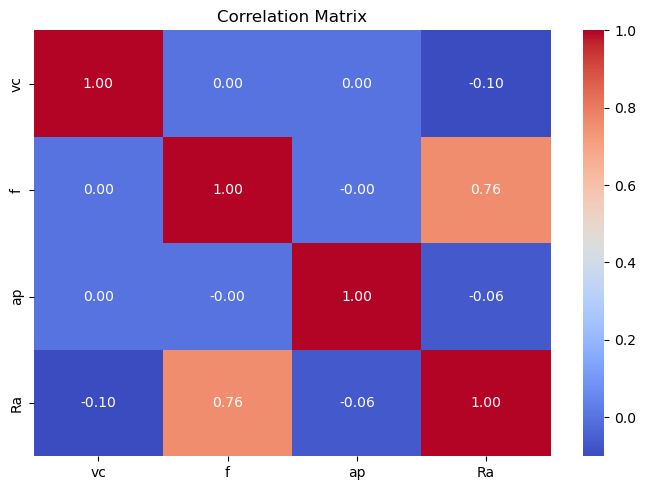

In [6]:
correlation = model_data.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Parameter Relationships

Scatter plots are used to visualize how surface roughness changes with each machining parameter.

These plots provide a clearer view of the experimental relationships before fitting the regression model.

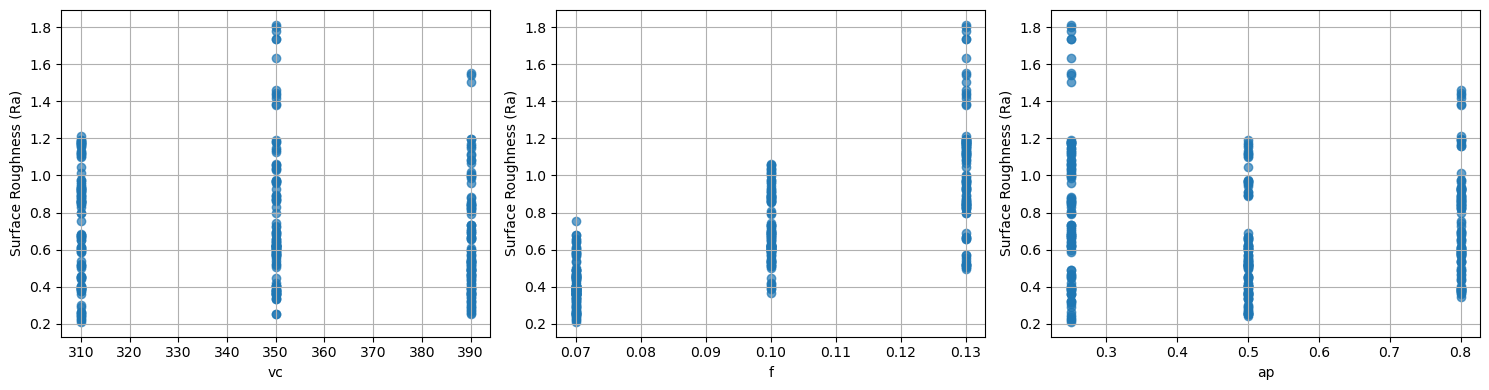

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

parameters = ['vc', 'f', 'ap']

for ax, parameter in zip(axes, parameters):
    ax.scatter(model_data[parameter], model_data['Ra'], alpha=0.7)
    ax.set_xlabel(parameter)
    ax.set_ylabel('Surface Roughness (Ra)')
    ax.grid(True)

plt.tight_layout()
plt.show()

### Observation

The exploratory plots show the individual relationships between the machining parameters and surface roughness.

The strength and direction of these relationships will be evaluated more systematically using multiple linear regression, where the effects of all three machining parameters are considered together.

## 6. Multiple Linear Regression

Multiple linear regression is used to model surface roughness as a function of cutting speed, feed rate, and depth of cut.

The model is defined as:

$$
R_a = \beta_0 + \beta_1v_c + \beta_2f + \beta_3a_p
$$

where:

- $R_a$ is surface roughness
- $v_c$ is cutting speed
- $f$ is feed rate
- $a_p$ is depth of cut
- $\beta_0$ is the intercept
- $\beta_1, \beta_2, \beta_3$ are the regression coefficients

In [8]:
X = model_data[['vc', 'f', 'ap']]
y = model_data['Ra']

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_:.4f}")

for name, coefficient in zip(X.columns, model.coef_):
    print(f"{name}: {coefficient:.4f}")

Intercept: 0.1023
vc: -0.0010
f: 10.1886
ap: -0.0933


### Regression Equation

The fitted coefficients define the estimated regression equation:

$$
\hat{R}_a = \beta_0 + \beta_1v_c + \beta_2f + \beta_3a_p
$$

Each coefficient represents the expected change in predicted surface roughness for a one-unit increase in that parameter, while the other parameters are held constant.

The coefficient signs indicate the direction of the fitted relationship.

In [9]:
print(
    f"Ra = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f})vc "
    f"+ ({model.coef_[1]:.4f})f "
    f"+ ({model.coef_[2]:.4f})ap"
)

Ra = 0.1023 + (-0.0010)vc + (10.1886)f + (-0.0933)ap


## 7. Model Evaluation

The fitted regression model is evaluated using three common regression metrics:

- **R²** measures the proportion of variation in surface roughness explained by the model.
- **MAE** measures the average absolute prediction error.
- **RMSE** measures the square root of the average squared prediction error and gives greater weight to larger errors.

In [10]:
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²   = {r2:.3f}")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")

R²   = 0.589
MAE  = 0.158
RMSE = 0.211


## 8. Train-Test Split

The dataset is divided into training and testing sets to evaluate how well the regression model generalizes to unseen observations.

The model is fitted using the training data, while the test data is kept separate for final evaluation.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Test R²   = {test_r2:.3f}")
print(f"Test MAE  = {test_mae:.3f}")
print(f"Test RMSE = {test_rmse:.3f}")

Test R²   = 0.620
Test MAE  = 0.155
Test RMSE = 0.215


### Training vs Test Performance

The training metrics describe how well the model fits the observations used during training.

The test metrics provide a more useful estimate of performance on unseen observations. Comparing the two helps identify whether the model generalizes reasonably well or shows signs of overfitting.

In [12]:
results = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Training': [r2, mae, rmse],
    'Test': [test_r2, test_mae, test_rmse]
})

results

,Metric,Training,Test
0,R²,0.589153,0.620209
1,MAE,0.157781,0.154744
2,RMSE,0.210990,0.214522


## 9. Cross-Validation

A single train-test split can depend on how the observations are divided.

To obtain a more robust estimate of model performance, 5-fold cross-validation is used. The dataset is divided into five parts, with each part used once as the validation set while the remaining data are used for training.

In [13]:
from sklearn.model_selection import KFold, cross_val_predict

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = cross_val_predict(
    LinearRegression(),
    X,
    y,
    cv=kf
)

cv_r2 = r2_score(y, cv_predictions)
cv_mae = mean_absolute_error(y, cv_predictions)
cv_rmse = np.sqrt(mean_squared_error(y, cv_predictions))

print(f"Cross-validation R²   = {cv_r2:.3f}")
print(f"Cross-validation MAE  = {cv_mae:.3f}")
print(f"Cross-validation RMSE = {cv_rmse:.3f}")

Cross-validation R²   = 0.579
Cross-validation MAE  = 0.160
Cross-validation RMSE = 0.214


## 10. Actual vs Predicted Surface Roughness

The cross-validated predictions are compared with the actual surface roughness values.

Because each prediction is generated from a model that did not train on that observation, this provides a more realistic visualization of predictive performance than using predictions from the model fitted to the full dataset.

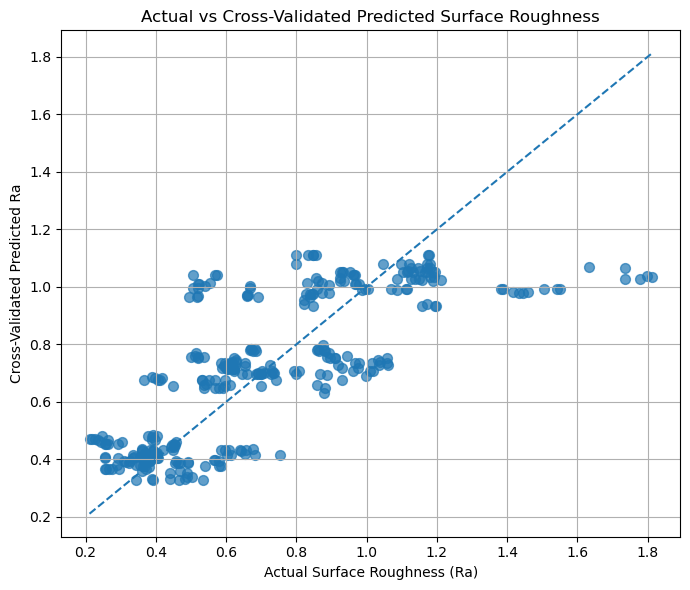

In [14]:
plt.figure(figsize=(7, 6))

plt.scatter(y, cv_predictions, s=50, alpha=0.7)

minimum = min(y.min(), cv_predictions.min())
maximum = max(y.max(), cv_predictions.max())

plt.plot([minimum, maximum], [minimum, maximum], '--')

plt.xlabel('Actual Surface Roughness (Ra)')
plt.ylabel('Cross-Validated Predicted Ra')
plt.title('Actual vs Cross-Validated Predicted Surface Roughness')

plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Residual Analysis

Residuals represent the difference between the actual and predicted surface roughness values.

A residual plot is used to check whether the prediction errors show any obvious systematic pattern. Ideally, residuals should be distributed around zero without a clear trend.

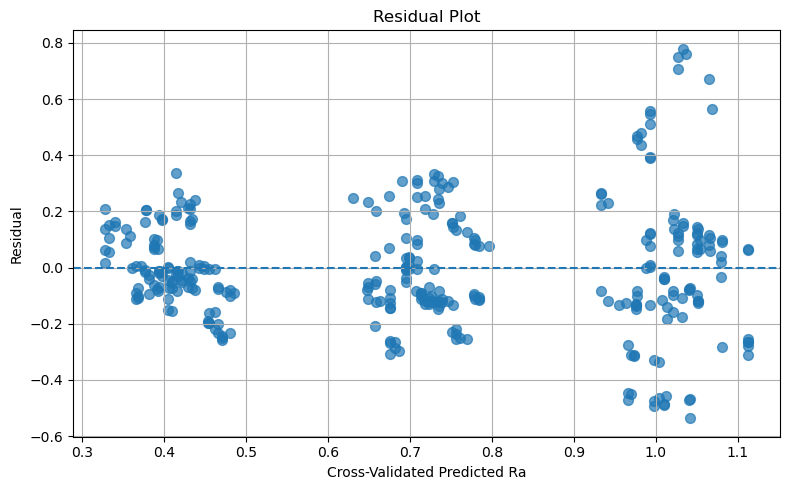

In [15]:
residuals = y - cv_predictions

plt.figure(figsize=(8, 5))

plt.scatter(cv_predictions, residuals, s=50, alpha=0.7)
plt.axhline(0, linestyle='--')

plt.xlabel('Cross-Validated Predicted Ra')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.grid(True)
plt.tight_layout()
plt.show()

### Residual Interpretation

The residual plot helps assess whether the regression model leaves systematic patterns in the prediction errors.

A random spread of residuals around zero is consistent with a reasonable linear fit, while visible trends or changing spread may indicate that the model does not fully capture the relationship in the data.

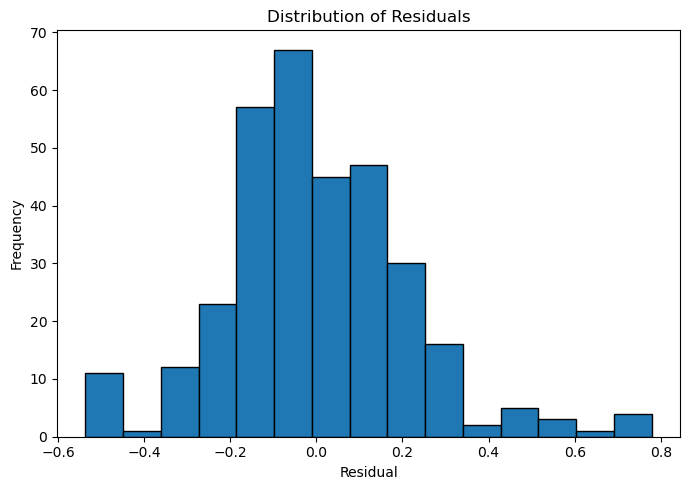

In [16]:
plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=15, edgecolor='black')

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

## 12. Feature Interpretation

The regression coefficients describe the direction of the fitted relationship between each machining parameter and surface roughness.

A positive coefficient indicates that increasing the parameter is associated with an increase in predicted surface roughness, while a negative coefficient indicates an inverse relationship, with the other parameters held constant.

The magnitude of the coefficients should be interpreted together with the units and scale of each machining parameter.

In [17]:
coefficients = pd.Series(model.coef_, index=X.columns)

coefficient_table = pd.DataFrame({
    'Parameter': coefficients.index,
    'Coefficient': coefficients.values
})

coefficient_table

,Parameter,Coefficient
0,vc,-0.000969
1,f,9.928713
2,ap,-0.061453


## 13. Feature Coefficients

The fitted coefficients are visualized to compare the direction and relative magnitude of the linear relationships represented by the model.

Because the machining parameters have different units and numerical scales, coefficient magnitude alone should not be used to rank the practical importance of the variables.

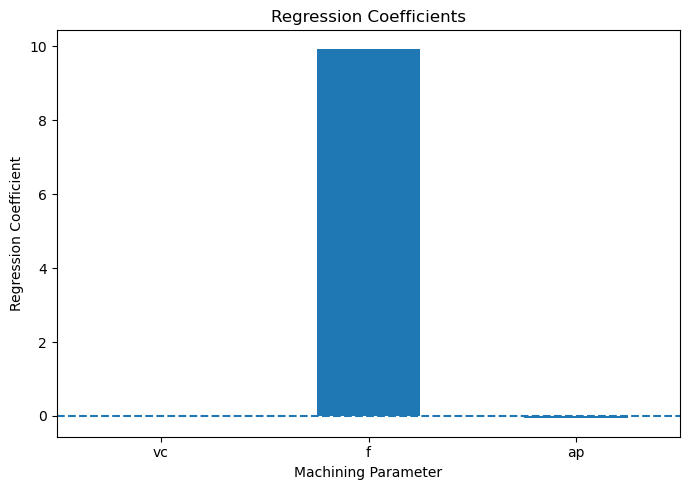

In [18]:
plt.figure(figsize=(7, 5))

coefficients.plot(kind='bar')

plt.axhline(0, linestyle='--')
plt.xlabel('Machining Parameter')
plt.ylabel('Regression Coefficient')
plt.title('Regression Coefficients')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Final Model Results

The regression model is summarized using both training performance and cross-validation performance.

Training metrics describe the fit to the available observations, while cross-validation metrics provide a more realistic estimate of how the model performs on unseen observations.

In [19]:
final_results = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Training': [r2, mae, rmse],
    'Test': [test_r2, test_mae, test_rmse],
    '5-Fold CV': [cv_r2, cv_mae, cv_rmse]
})

final_results

,Metric,Training,Test,5-Fold CV
0,R²,0.589153,0.620209,0.578916
1,MAE,0.157781,0.154744,0.160142
2,RMSE,0.210990,0.214522,0.213602


### Main Findings

The multiple linear regression model achieved an $R^2$ of 0.589 on the training data and 0.620 on the test data.

Five-fold cross-validation produced an $R^2$ of 0.579, with a mean absolute error of 0.160 and a root mean squared error of 0.214.

The similar training, test, and cross-validation results suggest that the model does not show strong evidence of overfitting on this dataset.

Among the fitted coefficients, feed rate has a positive relationship with predicted surface roughness, while cutting speed and depth of cut have negative coefficients. These coefficients describe the fitted linear relationships within the experimental conditions and should not be interpreted as causal effects.

Overall, the model provides a useful and interpretable baseline for relating the selected machining parameters to surface roughness.

## 15. Limitations

The analysis is based on one experimental dataset and a limited set of machining parameters.

Multiple linear regression assumes a linear relationship between the predictors and surface roughness, so nonlinear effects may not be fully captured.

The model should therefore be viewed as an interpretable baseline rather than a complete representation of machining behaviour.

Future work could investigate nonlinear models, additional machining variables, tool-condition effects, and larger experimental datasets.

## 16. Conclusion

This project used multiple linear regression to investigate the relationship between CNC turning parameters and surface roughness.

Cutting speed, feed rate, and depth of cut were used as explanatory variables, while surface roughness was used as the response variable.

The analysis included exploratory data analysis, correlation analysis, regression modelling, train-test evaluation, cross-validation, prediction analysis, and residual diagnostics.

The regression model provides an interpretable baseline for understanding how the selected machining parameters are related to surface roughness. However, its predictive performance should be interpreted within the experimental conditions represented by the dataset.

Further work could compare the linear model with nonlinear machine-learning methods and incorporate additional variables such as cutting forces and tool condition.